In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parámetros del modelo ---
kH = 5e3      # Constante cinética
Ceq = 2e-3    # Concentración de equilibrio
C0 = 0        # Concentración inicial de calcio

# --- Ecuación diferencial ---
def dCdt(C, pH):
    rate = kH * 10**(-pH)
    return rate * (1 - C/Ceq)

# --- Método de Euler (Paso a paso) ---
def euler_step(C, dt, pH):
    return C + dt * dCdt(C, pH)

# --- Método de Runge-Kutta 4 (Paso a paso) ---
def rk4_step(C, dt, pH):
    k1 = dCdt(C, pH)
    k2 = dCdt(C + 0.5 * dt * k1, pH)
    k3 = dCdt(C + 0.5 * dt * k2, pH)
    k4 = dCdt(C + dt * k3, pH)
    return C + dt * (k1 + 2*k2 + 2*k3 + k4) / 6

In [2]:
# --- Configuración de la simulación ---
dt = 0.01
tmax = 5
steps = int(tmax / dt)
time = np.linspace(0, tmax, steps)
pH_values = [5, 6, 7]

# --- Simulación ---
results_euler = {}
results_rk4 = {}

for pH in pH_values:
    # Simulación Euler
    C_euler = C0
    C_values_euler = []
    for _ in range(steps):
        C_values_euler.append(C_euler)
        C_euler = euler_step(C_euler, dt, pH)
    results_euler[pH] = np.array(C_values_euler)
    
    # Simulación RK4
    C_rk4 = C0
    C_values_rk4 = []
    for _ in range(steps):
        C_values_rk4.append(C_rk4)
        C_rk4 = rk4_step(C_rk4, dt, pH)
    results_rk4[pH] = np.array(C_values_rk4)

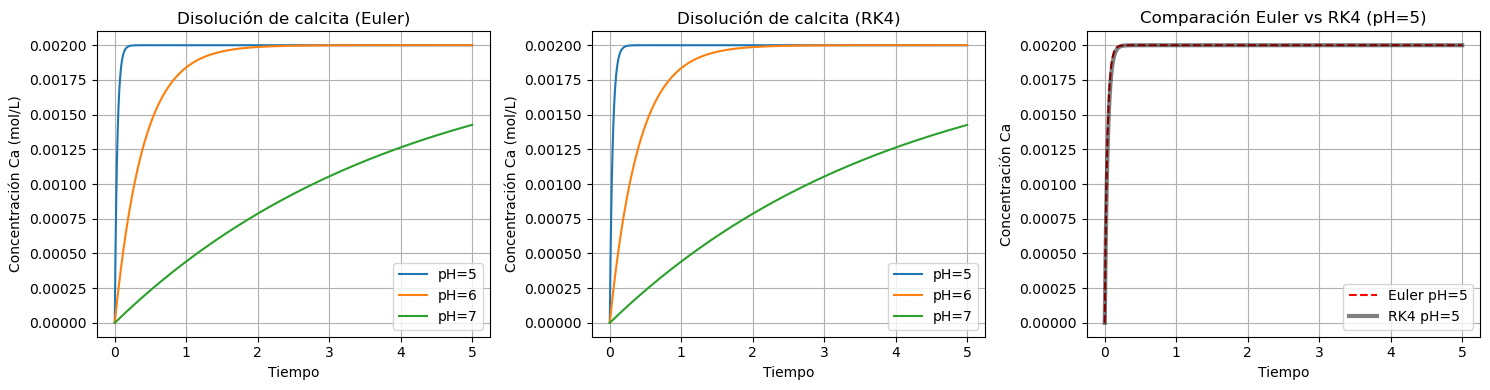

In [3]:
# --- Visualización (Gráficas) ---
plt.figure(figsize=(15, 4))

# Gráfica 1: Euler
plt.subplot(1, 3, 1)
for pH in pH_values:
    plt.plot(time, results_euler[pH], label=f"pH={pH}")
plt.xlabel("Tiempo")
plt.ylabel("Concentración Ca (mol/L)")
plt.title("Disolución de calcita (Euler)")
plt.legend()
plt.grid(True)

# Gráfica 2: RK4
plt.subplot(1, 3, 2)
for pH in pH_values:
    plt.plot(time, results_rk4[pH], label=f"pH={pH}")
plt.xlabel("Tiempo")
plt.ylabel("Concentración Ca (mol/L)")
plt.title("Disolución de calcita (RK4)")
plt.legend()
plt.grid(True)

# Gráfica 3: Comparación a pH=5
plt.subplot(1, 3, 3)
plt.plot(time, results_euler[5], 'r--', label="Euler pH=5")
plt.plot(time, results_rk4[5], 'k-', alpha=0.5, linewidth=3, label="RK4 pH=5")
plt.xlabel("Tiempo")
plt.ylabel("Concentración Ca")
plt.title("Comparación Euler vs RK4 (pH=5)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Respuestas conceptuales

**a) ¿Cómo afecta el pH la velocidad de disolución de calcita?**

La velocidad de disolución depende del término $10^{-pH}$, lo cual representa la concentración de protones $H^+$ en solución. Esto implica que:
* A **pH bajos** (medio más ácido), la concentración de $H^+$ es mayor.
* A **pH altos** (medio más básico), la concentración de $H^+$ es menor.

Por lo tanto, la velocidad de disolución de calcita es mayor a pH bajos y menor a pH altos.

---

**b) ¿Por qué la disolución es más rápida a pH bajos?**

La disolución de calcita está controlada por reacciones con protones. En medios ácidos hay una mayor concentración de $H^+$, lo que favorece directamente la reacción química. Los protones atacan la superficie del mineral y facilitan la liberación de calcio al agua, por lo que la disolución ocurre más rápidamente.

---

**c) ¿Qué ocurre cuando $C$ se aproxima a $C_{eq}$?**

En el modelo, la velocidad de reacción depende del factor $(1 - \frac{C}{C_{eq}})$. Cuando la concentración en solución ($C$) se aproxima al valor de equilibrio ($C_{eq}$), este término tiende a cero:

$$\frac{dC}{dt} \rightarrow 0$$

Esto significa que la velocidad de disolución disminuye progresivamente y el sistema se aproxima al equilibrio químico. En ese punto ya no hay disolución neta de calcita.

---

**5. ¿Cómo afecta el paso temporal $\Delta t$ a la estabilidad del modelo?**

El paso temporal controla la resolución numérica del modelo:
* Si $\Delta t$ es **pequeño**, la solución es más precisa y estable.
* Si $\Delta t$ es **muy grande**, el método de Euler puede producir errores importantes o incluso volverse inestable.

El método de Runge-Kutta de cuarto orden (RK4) es más preciso y estable que el método de Euler para un mismo paso temporal, porque evalúa la pendiente varias veces dentro de cada intervalo de tiempo. Por esta razón, RK4 suele proporcionar resultados más confiables en simulaciones numéricas de procesos geoquímicos.